Importei algumas bibliotecas inciais e dei uma vizualização dos dados

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

df = pd.read_csv('banco_box_sintetico.csv')
df.head(5)

,idade,renda_mensal,tempo_emprego,dividas_total,limite_cartao,historico_credito,num_cartoes_credito,num_emprestimos,atraso_pagamento,possui_imovel,possui_veiculo,cargo_atual,risco_credito
0,50,4145.83,1.4,5798,13957.29,1,1,1,0,Não,Não,Analista de TI,Médio
1,40,14080.13,0.9,39607,57549.72,1,0,2,0,Não,Não,Enfermeiro,Alto
2,59,7550.31,21.0,7865,20694.49,3,4,0,0,Não,Sim,Advogado,Médio
3,27,2390.01,5.6,1340,10593.18,17,5,3,0,Sim,Não,Analista de TI,Baixo
4,39,17135.27,20.3,45245,77949.94,1,3,2,0,Sim,Não,Contador,Alto


Dei uma olhada para ver se existe algum valor vazio

In [106]:
df.isna().sum()

,0
idade,0
renda_mensal,49
tempo_emprego,0
dividas_total,0
limite_cartao,0
historico_credito,0
num_cartoes_credito,0
num_emprestimos,0
atraso_pagamento,0
possui_imovel,0


Observei que tinha apenas na coluna "renda_mensal" e preechei com a media dos valores restantes

In [107]:
df['renda_mensal'].fillna(df['renda_mensal'].mean(), inplace=True)

/tmp/ipykernel_6079/3084342254.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['renda_mensal'].fillna(df['renda_mensal'].mean(), inplace=True)


Chequei se estava tudo nos conformes

In [108]:
df.isna().sum()

,0
idade,0
renda_mensal,0
tempo_emprego,0
dividas_total,0
limite_cartao,0
historico_credito,0
num_cartoes_credito,0
num_emprestimos,0
atraso_pagamento,0
possui_imovel,0


Dei uma olhada nos valores do "cargo_atual"

In [109]:
df['cargo_atual'].value_counts()

,count
cargo_atual,
Enfermeiro,117
Empreendedor,116
Analista de TI,112
Advogado,110
Contador,109
Designer,109
Médico,107
Professor,107
Engenheiro,97


Também percebi um irregularidade, logo fiz o tratamento

In [110]:
df['cargo_atual'] = df['cargo_atual'].replace(
    {'Eng.': 'Engenheiro','Prof.':'Professor','Prof':'Professor',
     'Analista TI':'Analista de TI','Analista_de_TI' :'Analista de TI'})

df['cargo_atual'].value_counts()

,count
cargo_atual,
Analista de TI,123
Enfermeiro,117
Empreendedor,116
Advogado,110
Professor,110
Contador,109
Designer,109
Médico,107
Engenheiro,99


Criei a nova coluna "relacao_divida_renda"

In [111]:
df['relacao_divida_renda'] = df['dividas_total']/df['renda_mensal']

df['relacao_divida_renda']

,relacao_divida_renda
0,1.398514
1,2.812971
2,1.041679
3,0.560667
4,2.640460
...,...
995,2.133747
996,0.929228
997,0.447934
998,2.878751


Fiz a analise de media do historico

In [112]:
media_credito = np.mean(df['historico_credito'])
print(f'Media do historico: {media_credito}')

Media do historico: 9.95


Plotei um grafico de barras vendo os risco de credito

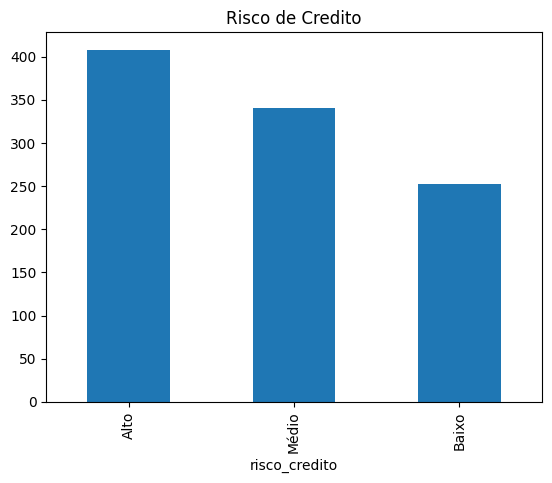

In [113]:
df['risco_credito'].value_counts().plot(kind='bar')
plt.title('Risco de Credito')
plt.show()

Fiz mais de um modelo para previsão de risco de credito. Imprimir o nome do modelo, a sua acuracia e também um grafico comparando os 4 modelos selecionado para a previsão

Modelo: Random Forest
Acuracia: 0.8766666666666667

Modelo: Arvore de Decisão
Acuracia: 0.8566666666666667



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Modelo: Regressão Logistica
Acuracia: 0.78

Modelo: KNN
Acuracia: 0.8266666666666667



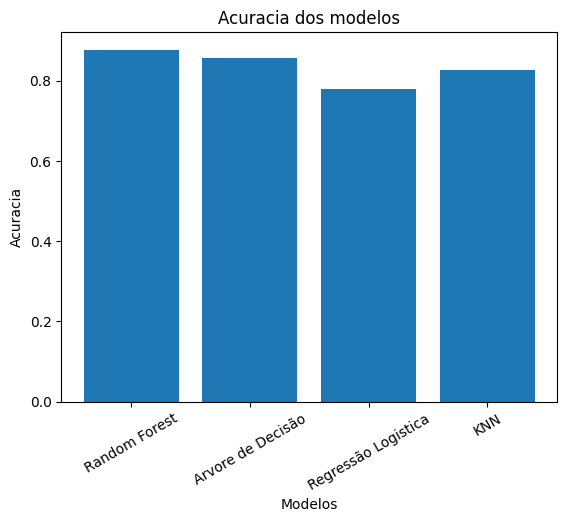

In [114]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

X = df[['renda_mensal','dividas_total','relacao_divida_renda']]
y = df['risco_credito']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3)

modelos = {
    'Random Forest': RandomForestClassifier(),
    'Arvore de Decisão': DecisionTreeClassifier(),
    'Regressão Logistica': LogisticRegression(),
    'KNN': KNeighborsClassifier()
}

resultado = {}

for nome, modelo in modelos.items():
  modelo.fit(X_train, y_train)
  y_pred = modelo.predict(X_test)

  acuracia = accuracy_score(y_test, y_pred)
  resultado[nome] = acuracia

  print(f'Modelo: {nome}')
  print(f'Acuracia: {acuracia}\n')

plt.bar(resultado.keys(),resultado.values())
plt.title('Acuracia dos modelos')
plt.xlabel('Modelos')
plt.ylabel('Acuracia')
plt.xticks(rotation=30)
plt.show()